<a href="https://colab.research.google.com/github/SeanMin00/Foundation-of-DataScience/blob/main/Foundation%20of%20Data%20Science%20Semester%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt

Link for the video

https://drive.google.com/file/d/1mztIREkXX7IO4Hu5ZtBBq2-4shpaMEUe/view?usp=drive_link

# 1. Introduction, Research Question, and Data

This project investigates whether daily macro news sentiment affects the probability that the next trading day's S&P 500 return is positive.

**Research Question:**  
Does daily macro news sentiment affect the probability of a positive next-day S&P 500 return?

**Estimand:**  
The causal effect of daily news sentiment on the probability that the next-day S&P 500 return is positive, controlling for same-day S&P 500 return.

We use daily macro news sentiment data and daily S&P 500 return data. The three variables in our causal model are:

- **Treatment / Cause (T):** daily macro news sentiment
- **Outcome / Result (Y):** whether the next-day S&P 500 return is positive
- **Confounder / Control (C):** same-day S&P 500 return

To facilitate binary classification, we transformed the continuous next_return into a dummy variable, next_up, which takes a value of 1 for positive returns and 0 otherwise.

# 2. Data Preprocessing

Before fitting the model, we cleaned and reorganized the data so that each row represents one causal comparison: today's news sentiment, today's market return, and whether the next trading day's market return is positive.

The final model variables are:

- **Treatment (T):** `treatment_sentiment`, copied from `daily_sentiment`
- **Outcome (Y):** `next_up`, equal to 1 if `next_return` is positive and 0 otherwise
- **Control (C):** `same_day_return`, copied from `daily_return`

We first created `next_return` by applying `shift(-1)` to the `daily_return` column. Then, we converted it into the binary outcome `next_up`. This matches our final research question, which focuses on whether the next-day return is positive, not the exact return size.

## 2.1 S&P 500 Return Calculation

We cleaned the S&P 500 index dataset and calculated daily returns from the closing price.

The daily return measures how much the S&P 500 changed compared to the previous trading day.

In [ ]:
import pandas as pd
df = pd.read_csv("sp500_index.csv")

df = df.drop(index=[0, 1]).copy()
df = df.rename(columns={"Price": "Date"})
df["Date"] = pd.to_datetime(df["Date"])

cols = ["Close", "High", "Low", "Open", "Volume"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)

df["daily_return"] = df["Close"].pct_change()
df["daily_return_pct(%)"] = df["daily_return"] * 100

print(df[["Date", "Close", "daily_return_pct(%)"]])

df[["Date", "daily_return_pct(%)"]].to_csv("daily_return_only.csv", index=False)

            Date        Close  daily_return_pct(%)
0     1980-01-02   105.760002                  NaN
1     1980-01-03   105.220001            -0.510591
2     1980-01-04   106.519997             1.235502
3     1980-01-07   106.809998             0.272250
4     1980-01-08   108.949997             2.003557
...          ...          ...                  ...
11651 2026-03-25  6591.899902             0.541912
11652 2026-03-26  6477.160156            -1.740617
11653 2026-03-27  6368.850098            -1.672184
11654 2026-03-30  6343.720215            -0.394575
11655 2026-03-31  6528.520020             2.913114

[11656 rows x 3 columns]


## 2.2 News Sentiment Data Collection, Filtering, and Daily Aggregation

We collected macro-related news sentiment data from the Alpha Vantage NEWS_SENTIMENT API for the years 2018 to 2025.  
The Alpha Vantage API key can be requested here: https://www.alphavantage.co/support/#api-key

**1. News Data Collection**

We used four macroeconomic topics from Alpha Vantage:

- `economy_macro`
- `economy_monetary`
- `economy_fiscal`
- `energy_transportation`

Because the API has request limits, we used a cache-based collection process. If the raw news file already existed, the code loaded the existing file and skipped topic-date windows that had already been collected. If the file did not exist, the code created it and saved new results as they were collected. This allowed us to resume data collection without starting over.

**2. Time Filtering**

After collecting the raw news articles, we converted each article's publication time to U.S. Eastern Time.  
Then, we kept only articles published before the U.S. market opened at **9:30 AM ET**.

This was done to reduce the chance of using articles that were written after the market had already reacted.

**3. Removing Market-Result Summary Articles**

We removed articles that mainly summarized market movements that had already happened, such as:

- stocks rising or falling
- S&P 500 closing higher or lower
- Dow or Nasdaq market wrap articles
- opening bell / closing bell articles

This helped reduce reverse timing problems where the article may describe the market movement instead of causing or predicting it.

**4. Macro Keyword Filtering**

Next, we filtered the articles using macroeconomic keywords such as:

- inflation, CPI, PPI, PCE
- Federal Reserve, FOMC, interest rates
- recession, GDP, unemployment, payrolls
- oil, energy, commodities
- war, sanctions, tariffs, supply chain

This helped keep articles that were more relevant to broad market-level macro sentiment.

**5. Daily Aggregation**

Finally, we aggregated the remaining article-level sentiment scores by date.

For each date, we calculated:

- `daily_sentiment`: average `overall_sentiment_score`
- `news_count`: number of articles used that day

The final daily sentiment dataset was saved as `daily_macro_sentiment_2018_2025.csv`.

In [ ]:
import os
import time
import requests
import pandas as pd

# Alpha Vantage API key
ALPHAVANTAGE_API_KEY = "YOUR_API_KEY"

# File paths
RAW_CACHE_PATH = "macro_news_2018_2025.csv"
FILTERED_NEWS_PATH = "macro_news_premarket_filtered_2018_2025.csv"
DAILY_SENTIMENT_PATH = "daily_macro_sentiment_2018_2025.csv"

BASE_AV_URL = "https://www.alphavantage.co/query"

# Macro-related topics used for news sentiment collection
TOPIC_LIST = [
    "economy_macro",
    "economy_monetary",
    "economy_fiscal",
    "energy_transportation"
]

SLEEP_SECONDS = 15


def halfyear_windows(start_year=2018, end_year=2025):
    windows = []
    for year in range(start_year, end_year + 1):
        windows.append((f"{year}0101T0000", f"{year}0630T2359"))
        windows.append((f"{year}0701T0000", f"{year}1231T2359"))
    return windows


def safe_request(url, params, sleep_seconds=SLEEP_SECONDS):
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    if isinstance(data, dict) and ("Note" in data or "Information" in data):
        print("API message:", data.get("Note") or data.get("Information"))
        return None

    time.sleep(sleep_seconds)
    return data


def load_existing_raw_cache(path):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded existing raw cache: {path} | rows={len(df)}")
        return df
    return pd.DataFrame()


def get_done_keys(existing_df):
    if existing_df.empty:
        return set()

    required_cols = {"topic", "time_from", "time_to"}
    if not required_cols.issubset(existing_df.columns):
        return set()

    done = (
        existing_df[["topic", "time_from", "time_to"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    return set(done)


def fetch_macro_news_resume(
    api_key,
    start_year=2018,
    end_year=2025,
    raw_cache_path=RAW_CACHE_PATH
):
    windows = halfyear_windows(start_year, end_year)

    existing = load_existing_raw_cache(raw_cache_path)
    done_keys = get_done_keys(existing)

    all_rows = []
    if not existing.empty:
        all_rows.append(existing)

    total_jobs = len(TOPIC_LIST) * len(windows)
    job_num = 0
    stop_all = False

    for topic in TOPIC_LIST:
        if stop_all:
            break

        for time_from, time_to in windows:
            job_num += 1
            key = (topic, time_from, time_to)

            if key in done_keys:
                print(f"[{job_num}/{total_jobs}] Skip cached: {topic} | {time_from} ~ {time_to}")
                continue

            print(f"[{job_num}/{total_jobs}] Fetching: {topic} | {time_from} ~ {time_to}")

            params = {
                "function": "NEWS_SENTIMENT",
                "topics": topic,
                "time_from": time_from,
                "time_to": time_to,
                "sort": "EARLIEST",
                "limit": 1000,
                "apikey": api_key
            }

            data = safe_request(BASE_AV_URL, params)

            if data is None:
                print("Stopped due to API limit/info message.")
                stop_all = True
                break

            feed = data.get("feed", [])

            if not feed:
                print("No articles found.")
                done_keys.add(key)
                continue

            df = pd.DataFrame(feed)
            df["topic"] = topic
            df["time_from"] = time_from
            df["time_to"] = time_to

            if "time_published" in df.columns:
                df["time_published"] = pd.to_datetime(
                    df["time_published"],
                    format="%Y%m%dT%H%M%S",
                    errors="coerce",
                    utc=True
                )

            keep_cols = [c for c in [
                "title",
                "url",
                "time_published",
                "summary",
                "source",
                "source_domain",
                "topics",
                "overall_sentiment_score",
                "overall_sentiment_label",
                "ticker_sentiment",
                "topic",
                "time_from",
                "time_to"
            ] if c in df.columns]

            df = df[keep_cols].copy()
            all_rows.append(df)
            done_keys.add(key)

            combined = pd.concat(all_rows, ignore_index=True).drop_duplicates(
                subset=["title", "url", "time_published", "topic", "time_from", "time_to"],
                keep="first"
            )

            combined.to_csv(raw_cache_path, index=False)
            print(f"Saved -> {raw_cache_path} | rows: {len(combined)}")

    if not all_rows:
        return pd.DataFrame()

    final_df = pd.concat(all_rows, ignore_index=True).drop_duplicates(
        subset=["title", "url", "time_published", "topic", "time_from", "time_to"],
        keep="first"
    )

    final_df.to_csv(raw_cache_path, index=False)
    return final_df


def build_filtered_outputs(
    raw_df,
    filtered_news_path=FILTERED_NEWS_PATH,
    daily_sentiment_path=DAILY_SENTIMENT_PATH
):
    news_df = raw_df.copy()

    # Convert publication time to datetime
    news_df["time_published"] = pd.to_datetime(
        news_df["time_published"],
        errors="coerce",
        utc=True
    )

    news_df = news_df.dropna(subset=["time_published"]).copy()

    # Convert time to U.S. Eastern Time
    news_df["time_et"] = news_df["time_published"].dt.tz_convert("America/New_York")
    news_df["Date"] = news_df["time_et"].dt.date
    news_df["hour_et"] = news_df["time_et"].dt.hour
    news_df["minute_et"] = news_df["time_et"].dt.minute

    # Keep only pre-market news before 9:30 AM ET
    news_df = news_df[
        (news_df["hour_et"] < 9) |
        ((news_df["hour_et"] == 9) & (news_df["minute_et"] < 30))
    ].copy()

    # Exclude articles that summarize market movements that already happened
    exclude_pattern = (
        r"stocks? (?:rise|rally|jump|gain|climb|fall|drop|slide|sink|tumble|rebound)|"
        r"stock market (?:rises|falls|drops|slides|rebounds)|"
        r"dow (?:rises|jumps|falls|drops|slides|ends|closes)|"
        r"dow jones (?:rises|jumps|falls|drops|slides|ends|closes)|"
        r"nasdaq (?:rises|jumps|falls|drops|slides|ends|closes)|"
        r"s&p 500 (?:rises|jumps|falls|drops|slides|ends|closes)|"
        r"wall street (?:rises|falls|drops|slides|ends|closes)|"
        r"markets? (?:rally|rise|fall|drop|slide|tumble|rebound)|"
        r"investors react|shares (?:rise|fall|drop|jump|slide)|"
        r"futures (?:rise|fall|drop|jump|slide)|"
        r"market wrap|closing bell|opening bell"
    )

    news_df = news_df[
        ~news_df["title"].astype(str).str.contains(
            exclude_pattern,
            case=False,
            na=False,
            regex=True
        )
    ].copy()

    # Keep macro-related news only
    macro_keywords = (
        r"inflation|cpi|ppi|pce|federal reserve|fed|fomc|interest rate|rate hike|rate cut|"
        r"monetary policy|fiscal policy|treasury yield|bond yield|yield curve|"
        r"recession|economic slowdown|gdp|unemployment|jobless claims|payrolls|nonfarm payrolls|"
        r"consumer spending|retail sales|manufacturing|pmi|ism|"
        r"oil|crude|energy crisis|natural gas|commodity|"
        r"war|ukraine|russia|middle east|china|taiwan|sanctions|tariffs|trade war|"
        r"supply chain|geopolitical|central bank|bank of japan|ecb"
    )

    news_df = news_df[
        news_df["title"].astype(str).str.contains(macro_keywords, case=False, na=False, regex=True) |
        news_df["summary"].astype(str).str.contains(macro_keywords, case=False, na=False, regex=True)
    ].copy()

    # Keep only articles with sentiment scores
    news_df = news_df.dropna(subset=["overall_sentiment_score"]).copy()

    # Combine with existing filtered file if it exists
    if os.path.exists(filtered_news_path):
        old_filtered = pd.read_csv(filtered_news_path)
        news_df = pd.concat([old_filtered, news_df], ignore_index=True).drop_duplicates(
            subset=["title", "url", "time_published"],
            keep="first"
        )

    news_df.to_csv(filtered_news_path, index=False)

    # Aggregate article-level sentiment into daily sentiment
    daily_sentiment = (
        news_df
        .groupby("Date")
        .agg(
            daily_sentiment=("overall_sentiment_score", "mean"),
            news_count=("overall_sentiment_score", "count")
        )
        .reset_index()
    )

    daily_sentiment.to_csv(daily_sentiment_path, index=False)

    return news_df, daily_sentiment


# 1) Collect raw macro news data
raw_news_df = fetch_macro_news_resume(
    api_key=ALPHAVANTAGE_API_KEY,
    start_year=2018,
    end_year=2025,
    raw_cache_path=RAW_CACHE_PATH
)

# 2) Filter raw news data and create daily sentiment dataset
news_df, daily_sentiment = build_filtered_outputs(
    raw_df=raw_news_df,
    filtered_news_path=FILTERED_NEWS_PATH,
    daily_sentiment_path=DAILY_SENTIMENT_PATH
)

print("RAW:", raw_news_df.shape)
print("FILTERED:", news_df.shape)
print("DAILY:", daily_sentiment.shape)
print(news_df[["Date", "time_et", "title", "overall_sentiment_score"]].head(10))
print(daily_sentiment.head(10))

[1/64] Fetching: economy_macro | 20180101T0000 ~ 20180630T2359
API message: We have detected your API key as YOUR_API_KEY and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.
Stopped due to API limit/info message.


KeyError: 'time_published'

## 2.3 Merging Daily Sentiment and S&P 500 Return Data


We merged the daily macro sentiment dataset with the S&P 500 daily return dataset by `Date`.

Before merging, we converted both `Date` columns into datetime format, renamed `daily_return_pct(%)` to `daily_return`, kept only the needed columns, removed duplicate dates, and restricted both datasets to their overlapping date range.

The final merged dataset contains one row per date with `daily_sentiment`, `news_count`, and `daily_return`. We saved this file as `macro_sentiment_with_daily_return.csv`.

In [ ]:
import pandas as pd

# 1) Load files
sent = pd.read_csv("daily_macro_sentiment_2018_2025.csv")
ret = pd.read_csv("daily_return_only.csv")

# 2) Convert Date columns and keep DATE only
sent["Date"] = pd.to_datetime(sent["Date"], errors="coerce").dt.normalize()
ret["Date"] = pd.to_datetime(ret["Date"], errors="coerce").dt.normalize()

# 3) Rename return column
ret = ret.rename(columns={"daily_return_pct(%)": "daily_return"})

# 4) Keep only needed columns
sent = sent[["Date", "daily_sentiment", "news_count"]].copy()
ret = ret[["Date", "daily_return"]].copy()

# 5) Force one row per Date in each dataset
sent = sent.sort_values("Date").drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)
ret = ret.sort_values("Date").drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)

# 6) Keep only overlapping period
overlap_start = max(sent["Date"].min(), ret["Date"].min())
overlap_end = min(sent["Date"].max(), ret["Date"].max())

sent = sent[(sent["Date"] >= overlap_start) & (sent["Date"] <= overlap_end)].copy()
ret = ret[(ret["Date"] >= overlap_start) & (ret["Date"] <= overlap_end)].copy()

# 7) Merge and keep unmatched values as null
df_merged = pd.merge(sent, ret, on="Date", how="outer")

# 8) Final safety check: one row per Date
df_merged = (
    df_merged
    .sort_values("Date")
    .drop_duplicates(subset=["Date"], keep="first")
    .reset_index(drop=True)
)

# 9) Check result
print("Overlap start:", overlap_start)
print("Overlap end:", overlap_end)
print("Duplicate dates after merge:", df_merged["Date"].duplicated().sum())
print(df_merged.head(20))

# 10) Save
df_merged.to_csv("macro_sentiment_with_daily_return.csv", index=False)

Overlap start: 2018-01-02 00:00:00
Overlap end: 2025-12-30 00:00:00
Duplicate dates after merge: 0
         Date  daily_sentiment  news_count  daily_return
0  2018-01-02         0.179596         3.0      0.830336
1  2018-01-03         0.371244         3.0      0.639882
2  2018-01-04              NaN         NaN      0.402864
3  2018-01-05              NaN         NaN      0.703377
4  2018-01-07         0.400676         1.0           NaN
5  2018-01-08        -0.333571         1.0      0.166234
6  2018-01-09         0.305194         2.0      0.130293
7  2018-01-10         0.264773         1.0     -0.111223
8  2018-01-11              NaN         NaN      0.703365
9  2018-01-12        -0.027380         3.0      0.674960
10 2018-01-15         0.429816         2.0           NaN
11 2018-01-16         0.338259        11.0     -0.352449
12 2018-01-17         0.253982         2.0      0.941505
13 2018-01-18         0.084019         3.0     -0.161639
14 2018-01-19         0.657712         2.0    

## 2.4 Model Variable Construction

After merging the daily sentiment and return datasets, we created the variables used in the causal model.

- `treatment_sentiment`: today's daily macro news sentiment
- `next_return`: next trading day's S&P 500 return, created using `shift(-1)`
- `next_up`: binary outcome equal to 1 if `next_return` is positive and 0 otherwise
- `same_day_return`: same-day S&P 500 return used as the control variable

We created `next_up` because our final research question focuses on market direction, not the exact size of the return.

In [ ]:
# Load merged dataset
merged_df = pd.read_csv("macro_sentiment_with_daily_return.csv")

# Convert Date and sort by time
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")
merged_df = merged_df.sort_values("Date").reset_index(drop=True)

# Treatment: today's news sentiment
merged_df["treatment_sentiment"] = merged_df["daily_sentiment"]

# Intermediate return variable: next trading day's return
merged_df["next_return"] = merged_df["daily_return"].shift(-1)

# Binary outcome: whether next-day return is positive
merged_df["next_up"] = (merged_df["next_return"] > 0).astype(int)

# Control: same-day S&P 500 return
merged_df["same_day_return"] = merged_df["daily_return"]

# Drop rows with missing model variables
df_clean = merged_df.dropna(
    subset=["treatment_sentiment", "next_return", "next_up", "same_day_return"]
).copy()

print(df_clean[["Date", "daily_sentiment", "daily_return", "next_return", "next_up", "same_day_return"]].head())
print(df_clean["next_up"].value_counts(normalize=True))

        Date  daily_sentiment  daily_return  next_return  next_up  \
0 2018-01-02         0.179596      0.830336     0.639882        1   
1 2018-01-03         0.371244      0.639882     0.402864        1   
5 2018-01-08        -0.333571      0.166234     0.130293        1   
6 2018-01-09         0.305194      0.130293    -0.111223        0   
7 2018-01-10         0.264773     -0.111223     0.703365        1   

   same_day_return  
0         0.830336  
1         0.639882  
5         0.166234  
6         0.130293  
7        -0.111223  
next_up
1    0.540046
0    0.459954
Name: proportion, dtype: float64


# 3. Causal Model / DAG

We use a three-variable causal model:

- **T = Treatment = Cause:** Daily macro news sentiment
- **Y = Outcome = Result:** Whether the next-day S&P 500 return is positive
- **C = Confounder / Control = Control:** Same-day S&P 500 return

The DAG is:

C → T  
C → Y  
T → Y

We treat same-day S&P 500 return as a potential confounder because current market movement may influence both the tone of market news and the probability of a positive return on the following trading day. Therefore, we control for same-day return when estimating the relationship between today's news sentiment and whether tomorrow's S&P 500 return is positive.
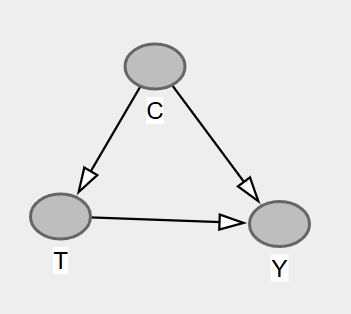

# 4. Statistical Model

We use a Bayesian logistic regression model because our outcome is binary: whether the next-day S&P 500 return is positive.

**Variables**

- **Yᵢ:** whether the next-day S&P 500 return is positive  
  - Yᵢ = 1 if next-day return > 0  
  - Yᵢ = 0 otherwise
- **Tᵢ:** daily macro news sentiment score
- **Cᵢ:** same-day S&P 500 return

**Likelihood**

Yᵢ ~ Bernoulli(pᵢ)

**Linear predictor**

logit(pᵢ) = α + βₜTᵢ + β꜀Cᵢ

The main parameter of interest is **βₜ**, which estimates how daily macro news sentiment is associated with the probability of a positive next-day return after controlling for same-day return.

**Priors**

α ~ Normal(0, 1)  
βₜ ~ Normal(0, 1)  
β꜀ ~ Normal(0, 1)

We used logit because we wanted a binary outcome

# 5. Simulated Data Validation

Before using the real data, we first tested whether our logistic model could recover known parameter values.

We created 2 fake datasets with the same structure as our final model:

- `T_sim`: simulated daily news sentiment
- `C_sim`: simulated same-day return
- `Y_sim`: simulated next-day direction

To generate this fake dataset, we set known true values:

- `alpha_true = 0.0`
- `beta_sentiment_true = 0.5`
- `beta_return_true = 0.5`

After generating the simulated data, we fit the same logistic model back to it.

The recovery check was successful because all three true values were inside the posterior HDI intervals. This suggests that the model works correctly in a controlled simulation setting and it was able to estimate the true values of the parameters.

After this validation step, we applied the same model to the real dataset.

In [ ]:
# Simulated Data Validation for Bayesian Logistic Regression
# This is unbiased simulation

np.random.seed(42)

# Define simulation size
N_sim = 2000

# Pre-defined true parameter values
alpha_true = 0.0
beta_sentiment_true = 0.5
beta_return_true = 0.5

# Simulate treatment and control variables
T_sim = np.random.normal(0, 1, N_sim)   # daily sentiment
C_sim = np.random.normal(0, 1, N_sim)   # same-day return

# Probability of positive next-day return
logit_p_sim = alpha_true + beta_sentiment_true * T_sim + beta_return_true * C_sim
p_sim = 1 / (1 + np.exp(-logit_p_sim))

# Binary outcome of next day's return
Y_sim = np.random.binomial(1, p_sim, N_sim)

# Fitting model to simulated data
with pm.Model() as simulated_logistic_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_sentiment = pm.Normal("beta_sentiment", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    logit_p = alpha + beta_sentiment * T_sim + beta_return * C_sim
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=Y_sim)

    idata_sim_logistic = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

# Arviz summary of posterior
summary_sim_logistic = az.summary(
    idata_sim_logistic,
    var_names=["alpha", "beta_sentiment", "beta_return"]
)

# Comparing posterior estimates with true values
true_values = pd.DataFrame({
    "true_value": {
        "alpha": alpha_true,
        "beta_sentiment": beta_sentiment_true,
        "beta_return": beta_return_true
    }
})

recovery_check_logistic = summary_sim_logistic[["mean", "hdi_3%", "hdi_97%"]].join(true_values)

recovery_check_logistic["recovered"] = (
    (recovery_check_logistic["true_value"] >= recovery_check_logistic["hdi_3%"]) &
    (recovery_check_logistic["true_value"] <= recovery_check_logistic["hdi_97%"])
)

print("Simulated Data Validation: Posterior Recovery Check")
display(recovery_check_logistic)

Output()

Simulated Data Validation: Posterior Recovery Check


,mean,hdi_3%,hdi_97%,true_value,recovered
alpha,-0.040,-0.131,0.052,0.0,True
beta_sentiment,0.542,0.443,0.633,0.5,True
beta_return,0.586,0.492,0.679,0.5,True


In [ ]:
# Simulated-data validation for the Bernoulli/logistic direction model
# This simulation follows the causal structure: C -> T, C -> Y, T -> Y
# This is biased simulation
np.random.seed(42)

N_sim = 2000

# Pre-defined true parameter values
alpha_true = 0.0
beta_sentiment_true = 0.5
beta_return_true = 0.5
gamma_true = 0.3   # Adding the bias of how much the prior day affects the news sentiment

# Simulate confounder first
C_sim = np.random.normal(0, 1, N_sim)

# Simulate treatment affected by the confounder
T_sim = gamma_true * C_sim + np.random.normal(0, 1, N_sim)

# Logistic linear predictor
logit_p_sim = alpha_true + beta_sentiment_true * T_sim + beta_return_true * C_sim

# Convert logit to probability
p_sim = 1 / (1 + np.exp(-logit_p_sim))

# Binary outcome
Y_sim = np.random.binomial(n=1, p=p_sim, size=N_sim)

sim_df = pd.DataFrame({
    "simulated_sentiment": T_sim,
    "simulated_return_control": C_sim,
    "simulated_next_up": Y_sim,
    "simulated_probability_next_up": p_sim
})

# sim_df.head()

# Fitting model to simulated data

with pm.Model() as simulated_logistic_model:
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_sentiment = pm.Normal("beta_sentiment", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    # Logistic linear predictor
    logit_p = alpha + beta_sentiment * T_sim + beta_return * C_sim

    # Probability of positive next-day return
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

    # Bernoulli likelihood
    obs = pm.Bernoulli("obs", p=p, observed=Y_sim)

    idata_simulated_logistic = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

summary_simulated_logistic = az.summary(
    idata_simulated_logistic,
    var_names=["alpha", "beta_sentiment", "beta_return"]
)

summary_simulated_logistic

# Compare posterior estimates with the pre-defined true parameter values

true_values_logistic = pd.DataFrame({
    "true_value": {
        "alpha": alpha_true,
        "beta_sentiment": beta_sentiment_true,
        "beta_return": beta_return_true
    }
})

recovery_check_logistic = summary_simulated_logistic[["mean", "hdi_3%", "hdi_97%"]].join(true_values_logistic)

recovery_check_logistic["recovered"] = (
    (recovery_check_logistic["true_value"] >= recovery_check_logistic["hdi_3%"]) &
    (recovery_check_logistic["true_value"] <= recovery_check_logistic["hdi_97%"])
)

recovery_check_logistic

Output()

,mean,hdi_3%,hdi_97%,true_value,recovered
alpha,-0.040,-0.130,0.046,0.0,True
beta_sentiment,0.585,0.487,0.677,0.5,True
beta_return,0.453,0.357,0.551,0.5,True


The simulated-data validation was successful. We generated fake data using estimated values: alpha_true = 0.0, beta_sentiment_true = 0.5, and beta_return_true = 0.5. After fitting the same logistic model to the simulated data, all three true values fell inside the posterior HDI intervals.
As a result, we can conclude that our model can estimate the parameter values.

# 6. Real Data Analysis and Posterior Diagnostics

After validating the model, we applied the same Bayesian logistic regression model to the real dataset.

The real dataset was `df_clean`, created from the merged file `macro_sentiment_with_daily_return.csv`.

The real model used:

- **T:** `treatment_sentiment`, today's macro news sentiment
- **C:** `same_day_return`, today's S&P 500 return
- **Y:** `next_up`, whether the next-day S&P 500 return was positive

Here, `next_up = 1` means the next-day return was positive, and `next_up = 0` means the next day's return was negative.

The model estimates whether today's news sentiment is associated with a higher probability of a positive next-day S&P 500 return, after controlling for same-day return.

The result showed that `beta_sentiment` was slightly positive but uncertain because its HDI included zero. In contrast, `beta_return` was clearly positive, meaning same-day S&P 500 return had a stronger relationship with next-day market direction.

The diagnostics looked reliable because `r_hat` values were close to 1.0, effective sample sizes were large, and there were no divergences.


In [ ]:
# Extract variables from the real dataset
T = df_clean["treatment_sentiment"].values
C = df_clean["same_day_return"].values
Y = df_clean["next_up"].values

# Fit Bayesian logistic regression to the real data
with pm.Model() as logistic_sentiment_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_sentiment = pm.Normal("beta_sentiment", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    logit_p = alpha + beta_sentiment * T + beta_return * C
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=Y)

    idata_logistic = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

summary_logistic = az.summary(
    idata_logistic,
    var_names=["alpha", "beta_sentiment", "beta_return"]
)

summary_logistic

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.151,0.063,0.039,0.276,0.001,0.001,3223.0,2865.0,1.0
beta_sentiment,0.097,0.254,-0.372,0.561,0.005,0.003,3095.0,3111.0,1.0
beta_return,-0.068,0.045,-0.155,0.017,0.001,0.001,4508.0,2873.0,1.0


# 7. Model Comparison and Posterior Predictive Check

In this section, we compare three Bayesian logistic regression models to evaluate whether daily news sentiment improves the model beyond same-day S&P 500 return.

We compare:

- **Baseline model:** uses no predictors  
  `next_up ~ 1`

- **Control-only model:** uses only same-day S&P 500 return  
  `next_up ~ same_day_return`

- **Full model:** uses both daily news sentiment and same-day return  
  `next_up ~ treatment_sentiment + same_day_return`

The key comparison is between the control-only model and the full model. If the full model performs better, this suggests that daily news sentiment adds predictive information beyond same-day return.

We use LOO for model comparison. Since all three models use the same binary outcome, `next_up`, the comparison is consistent.

After model comparison, we also perform a posterior predictive check for the full model. This checks whether the model can reproduce the observed proportion of positive next-day returns.

In [ ]:
# Model Comparison: Baseline vs Control-only vs Full Logistic Model
Y = df_clean["next_up"].values
T = df_clean["treatment_sentiment"].values
C = df_clean["same_day_return"].values

# 1) Baseline model: next_up ~ 1
with pm.Model() as model_baseline:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    p = pm.Deterministic("p", pm.math.invlogit(alpha))
    obs = pm.Bernoulli("obs", p=p, observed=Y)

    idata_baseline = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

# 2) Control-only model: next_up ~ same_day_return
with pm.Model() as model_control:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    logit_p = alpha + beta_return * C
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=Y)

    idata_control = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

# 3) Full model: next_up ~ sentiment + same_day_return
with pm.Model() as model_full:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_sentiment = pm.Normal("beta_sentiment", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    logit_p = alpha + beta_sentiment * T + beta_return * C
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=Y)

    idata_full = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

# Compare models using LOO
model_compare = {
    "baseline": idata_baseline,
    "control_only": idata_control,
    "full_sentiment_control": idata_full
}

compare_loo = az.compare(
    model_compare,
    ic="loo",
    scale="deviance"
)

compare_loo

Output()

Output()

Output()

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
control_only,0,1810.758278,1.971755,0.000000,5.520786e-01,6.512072,0.000000,False,deviance
baseline,1,1810.987476,0.986956,0.229199,4.479214e-01,5.835928,2.937388,False,deviance
full_sentiment_control,2,1812.484910,2.917197,1.726632,6.914255e-17,6.495272,0.756965,False,deviance


# 8. Sensitivity Analysis: Different Prediction Horizons

The one-day-ahead logistic model showed only a weak and uncertain sentiment effect. However, macro news may influence market direction with a short delay rather than only on the next trading day.

To check this possibility, we repeated the same logistic model across different prediction horizons. Instead of only testing whether today's sentiment predicts tomorrow's market direction, we tested whether today's sentiment is associated with positive S&P 500 returns from 1 to 10 trading days later.

For each horizon, we created a binary outcome:

- `up_1d`: return is positive 1 trading day later
- `up_2d`: return is positive 2 trading days later
- ...
- `up_30d`: return is positive 10 trading days later

We then fit the same Bayesian logistic regression model for each horizon:

Yᵢ,h ~ Bernoulli(pᵢ,h)

logit(pᵢ,h) = αₕ + β_sentiment,h Tᵢ + β_return,h Cᵢ

This sensitivity analysis checks whether the sentiment effect is immediate, delayed, or unstable across short-term horizons.

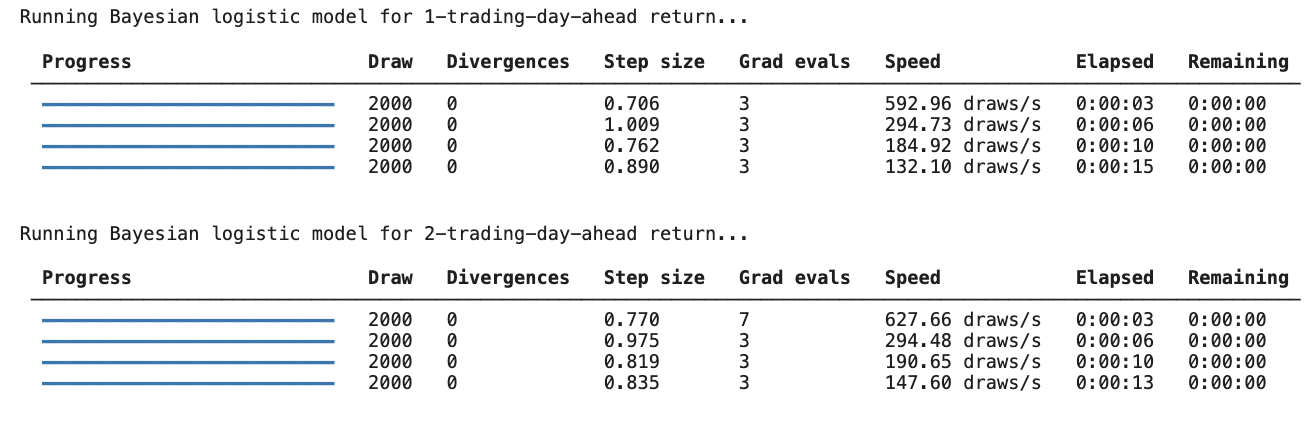

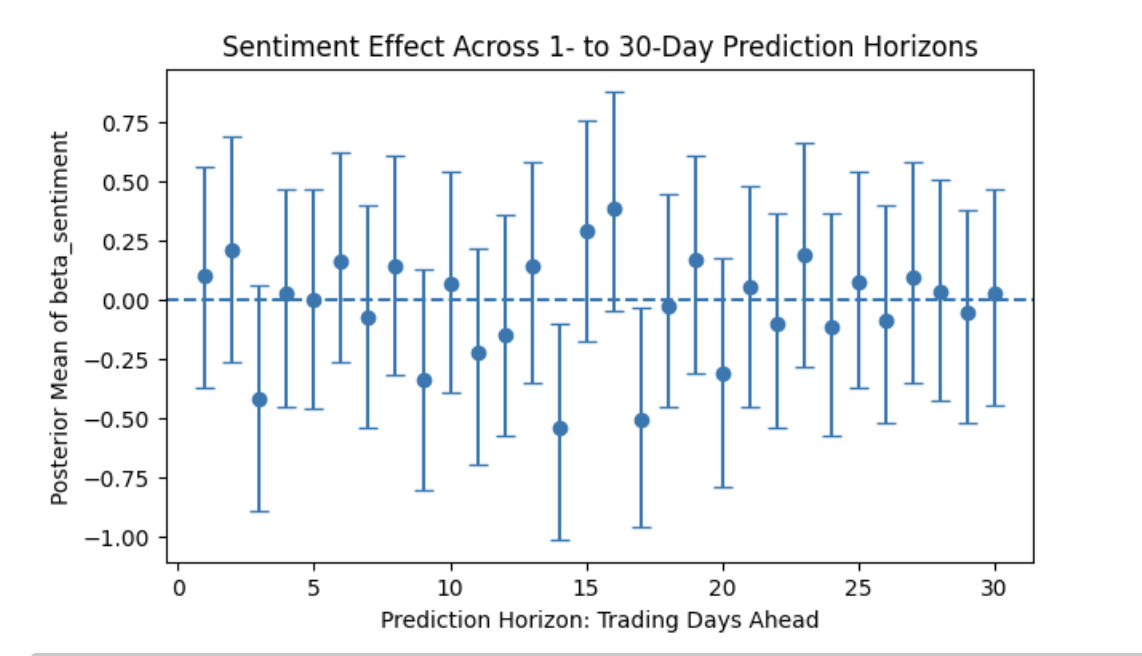

In [ ]:
# Sensitivity Analysis: 1- to 30-Day Prediction Horizons
# Goal: Test whether today's sentiment predicts market direction 1 to 5 trading days later
horizon_results = []

# Make sure merged_df is sorted by date
merged_df = merged_df.sort_values("Date").reset_index(drop=True)

for h in range(1, 31):
    print(f"\nRunning Bayesian logistic model for {h}-trading-day-ahead return...")

    temp_df = merged_df.copy()

    # Treatment: today's news sentiment
    temp_df["treatment_sentiment"] = temp_df["daily_sentiment"]

    # Control: same-day S&P 500 return
    temp_df["same_day_return"] = temp_df["daily_return"]

    # Outcome: h-trading-days-ahead return
    temp_df[f"return_{h}d_ahead"] = temp_df["daily_return"].shift(-h)

    # Binary outcome: 1 if h-day-ahead return is positive, 0 otherwise
    temp_df[f"up_{h}d"] = (temp_df[f"return_{h}d_ahead"] > 0).astype(int)

    # Clean modeling dataset
    temp_clean = temp_df.dropna(
        subset=[
            "treatment_sentiment",
            "same_day_return",
            f"return_{h}d_ahead",
            f"up_{h}d"
        ]
    ).copy()

    # Model variables
    T_h = temp_clean["treatment_sentiment"].values
    C_h = temp_clean["same_day_return"].values
    Y_h = temp_clean[f"up_{h}d"].values

    # Bayesian logistic regression
    with pm.Model() as horizon_model:
        alpha = pm.Normal("alpha", mu=0, sigma=1)
        beta_sentiment = pm.Normal("beta_sentiment", mu=0, sigma=1)
        beta_return = pm.Normal("beta_return", mu=0, sigma=1)

        logit_p = alpha + beta_sentiment * T_h + beta_return * C_h
        p = pm.Deterministic("p", pm.math.invlogit(logit_p))

        obs = pm.Bernoulli("obs", p=p, observed=Y_h)

        idata_h = pm.sample(
            draws=1000,
            tune=1000,
            chains=4,
            random_seed=42,
            idata_kwargs={"log_likelihood": True}
        )

    # Posterior summary
    summary_h = az.summary(
        idata_h,
        var_names=["alpha", "beta_sentiment", "beta_return"]
    )

    horizon_results.append({
        "horizon_days": h,
        "n_obs": len(temp_clean),

        "beta_sentiment_mean": summary_h.loc["beta_sentiment", "mean"],
        "beta_sentiment_hdi_3%": summary_h.loc["beta_sentiment", "hdi_3%"],
        "beta_sentiment_hdi_97%": summary_h.loc["beta_sentiment", "hdi_97%"],

        "beta_return_mean": summary_h.loc["beta_return", "mean"],
        "beta_return_hdi_3%": summary_h.loc["beta_return", "hdi_3%"],
        "beta_return_hdi_97%": summary_h.loc["beta_return", "hdi_97%"],

        "r_hat_sentiment": summary_h.loc["beta_sentiment", "r_hat"],
        "r_hat_return": summary_h.loc["beta_return", "r_hat"]
    })

# Convert results to DataFrame
horizon_results_df = pd.DataFrame(horizon_results)

# Add interpretation columns
horizon_results_df["sentiment_direction"] = np.where(
    horizon_results_df["beta_sentiment_mean"] > 0,
    "positive",
    "negative"
)

horizon_results_df["sentiment_hdi_includes_zero"] = (
    (horizon_results_df["beta_sentiment_hdi_3%"] <= 0) &
    (horizon_results_df["beta_sentiment_hdi_97%"] >= 0)
)

# Display summary table
display(
    horizon_results_df[
        [
            "horizon_days",
            "n_obs",
            "beta_sentiment_mean",
            "beta_sentiment_hdi_3%",
            "beta_sentiment_hdi_97%",
            "sentiment_direction",
            "sentiment_hdi_includes_zero",
            "beta_return_mean",
            "beta_return_hdi_3%",
            "beta_return_hdi_97%",
            "r_hat_sentiment"
        ]
    ]
)

# Plot sentiment effect by horizon
plt.figure(figsize=(7, 4))

plt.errorbar(
    horizon_results_df["horizon_days"],
    horizon_results_df["beta_sentiment_mean"],
    yerr=[
        horizon_results_df["beta_sentiment_mean"] - horizon_results_df["beta_sentiment_hdi_3%"],
        horizon_results_df["beta_sentiment_hdi_97%"] - horizon_results_df["beta_sentiment_mean"]
    ],
    fmt="o",
    capsize=4
)

plt.axhline(0, linestyle="--")
plt.xlabel("Prediction Horizon: Trading Days Ahead")
plt.ylabel("Posterior Mean of beta_sentiment")
plt.title("Sentiment Effect Across 1- to 30-Day Prediction Horizons")
plt.show()

In [ ]:
# Day-12 Follow-up Check + Model Comparison

h = 16

# 1) Create Day-16 dataset
day12_df = merged_df.copy().sort_values("Date").reset_index(drop=True)

day12_df["treatment_sentiment"] = day12_df["daily_sentiment"]
day12_df["same_day_return"] = day12_df["daily_return"]

day12_df["return_12d_ahead"] = day12_df["daily_return"].shift(-h)
day12_df["up_12d"] = (day12_df["return_12d_ahead"] > 0).astype(int)

day12_clean = day12_df.dropna(
    subset=[
        "treatment_sentiment",
        "same_day_return",
        "return_12d_ahead",
        "up_12d"
    ]
).copy()

T_12 = day12_clean["treatment_sentiment"].values
C_12 = day12_clean["same_day_return"].values
Y_12 = day12_clean["up_12d"].values

print("Day-12 dataset shape:", day12_clean.shape)
print("Observed positive rate at Day 12:", Y_12.mean())


# 2) Control-only model: up_12d ~ same_day_return
with pm.Model() as day12_control_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    logit_p = alpha + beta_return * C_12
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=Y_12)

    idata_day12_control = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )


# 3) Full model: up_12d ~ treatment_sentiment + same_day_return
with pm.Model() as day12_full_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_sentiment = pm.Normal("beta_sentiment", mu=0, sigma=1)
    beta_return = pm.Normal("beta_return", mu=0, sigma=1)

    logit_p = alpha + beta_sentiment * T_12 + beta_return * C_12
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=Y_12)

    idata_day12_full = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )


# 4) Posterior summary for Day-12 full model
summary_day12 = az.summary(
    idata_day12_full,
    var_names=["alpha", "beta_sentiment", "beta_return"]
)

print("Day-16 Full Model Posterior Summary")
display(summary_day12)


# 5) Posterior probability that sentiment effect is positive
posterior_day12 = az.extract(idata_day12_full)

prob_beta_sentiment_positive = (
    posterior_day12["beta_sentiment"].values > 0
).mean()

print(f"P(beta_sentiment > 0) for Day-16 horizon: {prob_beta_sentiment_positive:.2%}")


# 6) Day-12 model comparison using LOO
compare_day12 = az.compare(
    {
        "day12_control_only": idata_day12_control,
        "day12_full_sentiment_control": idata_day12_full
    },
    ic="loo",
    scale="deviance"
)

print("Day-16 Model Comparison")
display(compare_day12)

# 9. Results, Conclusion, and Future Work

## Conclusion

This project tested whether daily macro news sentiment can predict the direction of future S&P 500 returns.

First, the **next-day logistic model** showed that sentiment had only a weak and uncertain effect. The sentiment coefficient was slightly positive, but its HDI included zero. In contrast, same-day return showed a much stronger and clearer positive relationship with next-day market direction.

Second, the **model comparison** showed that the control-only model performed best. Adding sentiment did not meaningfully improve prediction beyond same-day S&P 500 return.

Third, the **horizon sensitivity analysis** showed that sentiment was not stable across 1- to 30-trading-day horizons. Some horizons were positive, while others were negative.

The strongest result appeared at the **16-trading-day horizon**, where sentiment showed a clear positive coefficient. However, because Day 16 was selected after checking many horizons, this should be treated as an exploratory finding, not a final causal conclusion.

Overall, daily macro news sentiment does not appear to be a reliable short-term predictor of S&P 500 direction. However, the Day-16 result suggests a possible delayed sentiment effect that could be tested more carefully in future work.

## Future Work

For future work, although our current model is statistically reasonable, the predictive power of daily news sentiment for next-day market direction is still limited.

There are three possible ways to improve this project.

First, we could refine the sentiment variable. Instead of using only one daily average sentiment score, we could separate positive news and negative news, because they may affect the market differently.

Second, we could use higher-frequency data. In this project, we aggregated news sentiment by day, but some market reactions may happen within a few hours or even minutes. These short-term effects may be washed out when we only use daily data.

Third, we could expand the causal model by adding more macroeconomic variables, such as inflation indicators and interest rates. Including these more influential variables could help us better control for the broader economic environment and better isolate the relationship between public sentiment and stock market direction.

# 10. Group Participation Summary

Our group divided the project work across the main parts of the analysis: data preparation, model development, validation, real-data analysis, sensitivity analysis, and final write-up.

- **Gideok Min:** Worked on **data preprocessing, model variable construction, and sensitivity analysis**. He cleaned the S&P 500 return data, merged it with the daily macro news sentiment dataset, created the final modeling variables such as `treatment_sentiment`, `same_day_return`, `next_return`, and `next_up`, and checked the final modeling dataset. He also conducted the 1- to 30-trading-day horizon sensitivity analysis and added the Day-12 follow-up check to examine a possible delayed sentiment effect.

- **Liyan Cheung:** Worked on **the Bayesian logistic model setup and implementation**. He helped define the binary outcome structure, Bernoulli likelihood, logit link function, priors, and main model parameters. He also contributed to fitting the initial logistic model and connecting the model structure to the research question.

- **Xingjian Liu:** Worked on **causal framing, model validation, real-data analysis, model comparison, and final interpretation**. He helped refine the research question, organize the causal model and DAG explanation, and connect the statistical model to the causal structure. He also contributed to the simulated-data validation, posterior diagnostics, LOO model comparison, and interpretation of the real-data results. In addition, he helped organize the final notebook structure and write the results, conclusion, and limitations sections.

Overall, the team collaborated across all major project steps: research question, data preprocessing, causal model, statistical model, simulated-data validation, real-data analysis, model comparison, sensitivity analysis, results, conclusion, and limitations.